In [2]:
import matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import r2_score, f1_score, make_scorer, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report, precision_recall_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
from scipy import stats

In [3]:
# 1. data cleaning
# load dataset
df = pd.read_csv('../Bank-Term-Deposit-Subscription-Prediction/Data/bank-additional/bank-additional-full.csv', sep=';')
print(f"columns of df:\n{df.columns}")

# delete duration
df = df.drop(columns=['duration'])

# unified missing value
df.replace('unknown', np.nan, inplace=True)

# create X and y
df['y'] = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])
y = df['y']

columns of df:
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


In [4]:
# 2. splitting
# stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"training and validation set shape: {X_train.shape}")
print(f"testing set shape: {X_test.shape}")

training and validation set shape: (32950, 19)
testing set shape: (8238, 19)


Correlation Matrix:
               emp.var.rate  euribor3m  nr.employed
emp.var.rate      1.000000   0.972245     0.906970
euribor3m         0.972245   1.000000     0.945154
nr.employed       0.906970   0.945154     1.000000


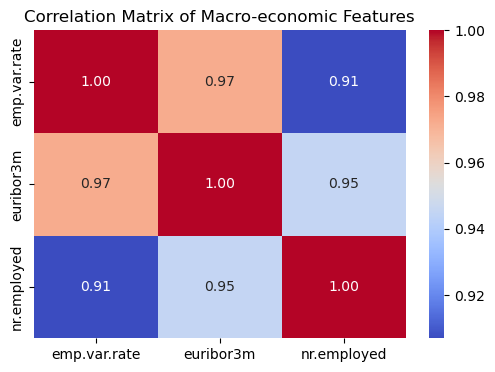

        Feature  R2 (Explained by others)  Correlation with Target
0  emp.var.rate                  0.743968                -0.293690
1     euribor3m                  0.662549                -0.303174
2   nr.employed                  0.506264                -0.349729


In [5]:
# decide which to drop
corr_matrix = df[['emp.var.rate', 'euribor3m', 'nr.employed']].corr()

print("Correlation Matrix:\n", corr_matrix)

# plot
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Macro-economic Features")
plt.show()

macro_cols = ['emp.var.rate', 'euribor3m', 'nr.employed']
other_cols = [col for col in X_train.columns if col not in macro_cols]

cat_cols = X_train[other_cols].select_dtypes(include=['object']).columns
num_cols = X_train[other_cols].select_dtypes(include=['number']).columns

preprocessor_analysis = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), cat_cols)
    ]
)

X_rest_processed = preprocessor_analysis.fit_transform(X_train[other_cols])

results = []

for feature_name in macro_cols:
    y_feat = X_train[feature_name]
    
    lr = LinearRegression()
    lr.fit(X_rest_processed, y_feat)
    y_feat_pred = lr.predict(X_rest_processed)
    
    r2 = r2_score(y_feat, y_feat_pred)
    
    correlation = y_feat.corr(y_train)
    
    results.append({
        "Feature": feature_name,
        "R2 (Explained by others)": r2,
        "Correlation with Target": correlation
    })

results_df = pd.DataFrame(results)
print(results_df)

In [10]:
# reorganized
cols_to_drop = ['emp.var.rate', 'euribor3m']
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

# feature grouping
# ordinal
education_order = [
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 
    'high.school', 'professional.course', 'university.degree'
]
month_order = [
    'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
] 
day_order = ["mon", "tue", "wed", "thu", "fri"]
ord_cols = ['education', 'month', 'day_of_week']

# numerical
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# nominal
nom_cols = [col for col in X_train.select_dtypes(include=['object']).columns if col not in ord_cols]

print(f"\ncheck type split:")
print(f"numerial ({len(num_cols)}): {num_cols}")
print(f"ordinal({len(ord_cols)}): {ord_cols}")
print(f"nominal ({len(nom_cols)}): {nom_cols}")

# pipeline
numeric_pipeline = Pipeline([('scaler', StandardScaler())])
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('ordinal', OrdinalEncoder(categories=[education_order, month_order, day_order]))
])
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('ord', ordinal_pipeline, ord_cols),
    ('nom', nominal_pipeline, nom_cols)
])

# fit and transform
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"\nfeature count: {X_train_prep.shape[1]}")
print(f"X_train_prep shape: {X_train_prep.shape}")
print(f"X_test_prep shape: {X_test_prep.shape}")


check type split:
numerial (7): ['age', 'campaign', 'pdays', 'previous', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
ordinal(3): ['education', 'month', 'day_of_week']
nominal (7): ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome']

feature count: 40
X_train_prep shape: (32950, 40)
X_test_prep shape: (8238, 40)


In [12]:
# subsample
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print(f"  Inner Train:    {X_train_inner.shape[0]:5d} samples (For model fitting)")
print(f"  Validation:     {X_val.shape[0]:5d} samples (For model selection)")
print(f"  Test (held):    {X_test.shape[0]:5d} samples (For final report only)")

n_samples_tune = 4000 

print(f"from {X_train.shape[0]} training data to subsample {n_samples_tune} as tuning")

X_tune, y_tune = resample(
    X_train_inner, y_train_inner, 
    n_samples=n_samples_tune, 
    replace=False, 
    stratify=y_train_inner, 
    random_state=42
)

print(f"dataset for tuning: {X_tune.shape}")
print(f"proportion: {y_tune.mean():.2%}")

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ratio = float(np.sum(y_train_inner == 0)) / np.sum(y_train_inner == 1)

C_range = np.logspace(-3, 3, 7) 
gamma_range = np.logspace(-3, 3, 7)

# model parameter setup
model_configs = {
    # 1. Logistic Regression
    "Logistic Regression": {
        "model": LogisticRegression(class_weight='balanced', solver='saga', max_iter=5000, random_state=42),
        "params": {
            'classifier__C': C_range, 
            'classifier__penalty': ['l1', 'l2'] 
        }
    },

    # 2. SVM 
    "SVM": {
        "model": SVC(class_weight='balanced', probability=True, random_state=42, cache_size=1000),
        "params": {
            'classifier__C': [0.1, 1, 10, 100],
            'classifier__gamma': [0.0001, 0.0005, 0.001],
            'classifier__kernel': ['rbf']
        }
    },
    
    # 3. KNN
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            'classifier__n_neighbors': [2, 3, 5, 7],
            'classifier__weights': ['uniform', 'distance'],
            'classifier__p': [1, 2],
            'classifier__algorithm': ['auto', 'ball_tree']
        }
    },
    
    # 4. Random Forest (Bagging)
    "Random Forest": {
        "model": RandomForestClassifier(class_weight='balanced', random_state=42),
        "params": {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [10, 15, 30, 50],
            'classifier__min_samples_split': [10, 20, 40],
            'classifier__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7]
        }
    },

    # 5. XGBoost (Boosting)
    "XGBoost": {
        "model":XGBClassifier(
        n_estimators=5000,         
        early_stopping_rounds=50, 
        scale_pos_weight=ratio, 
        eval_metric='logloss', 
        random_state=42
    ),
        "params": {
            'classifier__learning_rate': [0.001, 0.005, 0.01],
            'classifier__max_depth': [5, 7, 9, 11],
            'classifier__subsample': [0.5, 0.6, 0.7, 0.8],
            'classifier__reg_lambda': [0, 0.01, 0.05, 0.1]
        }
    }
}

  Inner Train:    26360 samples (For model fitting)
  Validation:      6590 samples (For model selection)
  Test (held):     8238 samples (For final report only)
from 32950 training data to subsample 4000 as tuning
dataset for tuning: (4000, 17)
proportion: 11.28%


In [14]:
results_list = []

for name, config in model_configs.items():
    stage_start = time.time()
    print(f"\n[{name}] Tuning...")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    
    if name == "XGBoost":
        X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
            X_tune, y_tune,
            test_size=0.2,
            stratify=y_tune,
            random_state=42
        )
        
        X_tune_train_proc = preprocessor.fit_transform(X_tune_train, y_tune_train)
        X_tune_val_proc = preprocessor.transform(X_tune_val)
        
        fit_params = {
            'classifier__eval_set': [(X_tune_val_proc, y_tune_val)],
            'classifier__verbose': False
        }
        
        X_for_cv = X_tune_train
        y_for_cv = y_tune_train
        
    else:
        fit_params = {}
        X_for_cv = X_tune
        y_for_cv = y_tune
    
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=kf,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )
    
    grid.fit(X_for_cv, y_for_cv, **fit_params)
    
    best_params = grid.best_params_
    tune_score = grid.best_score_
    tune_std = grid.cv_results_['std_test_score'][grid.best_index_]
    
    print(f"Best Params: {best_params}")
    print(f"Tuning CV Score: {tune_score:.4f} (±{tune_std:.4f})")
    
    # Refit on Inner Train
    final_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    final_pipeline.set_params(**best_params)
    
    # Special handling for XGBoost with early stopping
    if name == "XGBoost":
        print("  (Refitting with Early Stopping on Validation Set)")
        
        transformer = final_pipeline.named_steps['preprocessor']
        classifier = final_pipeline.named_steps['classifier']
        
        X_train_proc = transformer.fit_transform(X_train_inner, y_train_inner)
        X_val_proc = transformer.transform(X_val)
        
        classifier.fit(
            X_train_proc, y_train_inner,
            eval_set=[(X_val_proc, y_val)],
            verbose=False
        )

        print(f"  ★ Phase 2 Final Stop: Iteration {classifier.best_iteration}")
        
        y_val_pred = classifier.predict(X_val_proc)
        
    else:
        final_pipeline.fit(X_train_inner, y_train_inner)
        y_val_pred = final_pipeline.predict(X_val)
    
    # Validation Score
    val_score = f1_score(y_val, y_val_pred, average='macro')
    
    print(f"Validation F1-Macro: {val_score:.4f} which will be Used for ranking")
    
    elapsed = time.time() - stage_start
    print(f"Total time: {elapsed:.1f}s")
    
    # Store results (NO TEST SCORE YET!)
    results_list.append({
        "Model": name,
        "Tuning CV Score": tune_score,
        "Tuning Std": tune_std,
        "Validation F1": val_score,
        "Best Parameters": str(best_params),
        "Pipeline": final_pipeline if name != "XGBoost" else (transformer, classifier),  # Store for later use
        "Time (s)": round(elapsed, 1)
    })


[Logistic Regression] Tuning...
Best Params: {'classifier__C': np.float64(0.1), 'classifier__penalty': 'l2'}
Tuning CV Score: 0.6222 (±0.0201)
Validation F1-Macro: 0.6316 which will be Used for ranking
Total time: 8.5s

[SVM] Tuning...
Best Params: {'classifier__C': 1, 'classifier__gamma': 0.0001, 'classifier__kernel': 'rbf'}
Tuning CV Score: 0.6566 (±0.0340)
Validation F1-Macro: 0.5857 which will be Used for ranking
Total time: 494.6s

[KNN] Tuning...
Best Params: {'classifier__algorithm': 'auto', 'classifier__n_neighbors': 7, 'classifier__p': 2, 'classifier__weights': 'distance'}
Tuning CV Score: 0.6421 (±0.0451)
Validation F1-Macro: 0.6487 which will be Used for ranking
Total time: 2.2s

[Random Forest] Tuning...
Best Params: {'classifier__max_depth': 15, 'classifier__max_features': 'log2', 'classifier__min_samples_split': 20, 'classifier__n_estimators': 100}
Tuning CV Score: 0.6815 (±0.0296)
Validation F1-Macro: 0.7101 which will be Used for ranking
Total time: 88.2s

[XGBoost] Tu

In [18]:
# MODEL SELECTION (Based on Validation Performance)
print(f"\n{'='*80}")
print("MODEL SELECTION (Based on Validation Set)")
print(f"{'='*80}")

results_df = pd.DataFrame(results_list).sort_values(
    by="Validation F1", ascending=False
)

print("\nValidation Performance Ranking:")
display_df = results_df[[
    "Model", "Tuning CV Score", "Tuning Std", "Validation F1", "Time (s)"
]].copy()
display_df.index = range(1, len(display_df) + 1)
print(display_df.to_string())

# Select best model
best_model_row = results_df.iloc[0]
best_model_name = best_model_row["Model"]
best_model_pipeline = best_model_row["Pipeline"]
best_val_score = best_model_row["Validation F1"]

print(f"\n{'='*80}")
print("BEST MODEL SELECTED")
print(f"{'='*80}")
print(f"Winner: {best_model_name}")
print(f"  Validation F1: {best_val_score:.4f}")
print(f"  Best Params: {best_model_row['Best Parameters']}")
print(f"{'='*80}")


MODEL SELECTION (Based on Validation Set)

Validation Performance Ranking:
                 Model  Tuning CV Score  Tuning Std  Validation F1  Time (s)
1        Random Forest         0.681518    0.029609       0.710076      88.2
2              XGBoost         0.678364    0.020451       0.702175     313.9
3                  KNN         0.642119    0.045083       0.648704       2.2
4  Logistic Regression         0.622246    0.020110       0.631635       8.5
5                  SVM         0.656588    0.033963       0.585730     494.6

BEST MODEL SELECTED
Winner: Random Forest
  Validation F1: 0.7101
  Best Params: {'classifier__max_depth': 15, 'classifier__max_features': 'log2', 'classifier__min_samples_split': 20, 'classifier__n_estimators': 100}


In [20]:
# FINAL EVALUATION ON TEST SET
print(f"\n{'='*80}")
print("FINAL EVALUATION ON TEST SET")
print(f"{'='*80}")

# Evaluate best model on test set
if best_model_name == "XGBoost":
    # Special handling for XGBoost
    X_test_proc = best_model_pipeline.named_steps['preprocessor'].transform(X_test)
    y_test_pred = best_model_pipeline.named_steps['classifier'].predict(X_test_proc)
else:
    y_test_pred = best_model_pipeline.predict(X_test)

test_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"{'='*80}")
print(f"FINAL TEST PERFORMANCE: {best_model_name}")
print(f"{'='*80}")
print(f"Test F1-Macro: {test_f1:.4f}")
print(f"\nComparison:")
print(f"  Tuning CV Score:  {best_model_row['Tuning CV Score']:.4f}")
print(f"  Validation Score: {best_val_score:.4f}")
print(f"  Test Score:       {test_f1:.4f}")
print(f"\nGeneralization Gaps:")
print(f"  Val - Tuning: {best_val_score - best_model_row['Tuning CV Score']:+.4f}")
print(f"  Test - Val:   {test_f1 - best_val_score:+.4f}")

# Detailed classification report
print(f"\n{'='*80}")
print("DETAILED CLASSIFICATION REPORT")
print(f"{'='*80}")
print(classification_report(y_test, y_test_pred, target_names=['No', 'Yes']))



FINAL EVALUATION ON TEST SET
FINAL TEST PERFORMANCE: Random Forest
Test F1-Macro: 0.7182

Comparison:
  Tuning CV Score:  0.6815
  Validation Score: 0.7101
  Test Score:       0.7182

Generalization Gaps:
  Val - Tuning: +0.0286
  Test - Val:   +0.0081

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.95      0.90      0.92      7310
         Yes       0.44      0.61      0.51       928

    accuracy                           0.87      8238
   macro avg       0.69      0.76      0.72      8238
weighted avg       0.89      0.87      0.88      8238



In [22]:
# Assessment of Uncertainty
ratio = float(np.sum(y == 0)) / np.sum(y == 1)

best_rf_params = {
    'max_depth': 15,            
    'max_features': 'log2',    
    'min_samples_split': 20,  
    'n_estimators': 100        
}

print("CHAMPION MODEL (Random Forest):")
for key, value in best_rf_params.items():
    print(f"  {key:20s}: {value}")

CHAMPION MODEL (Random Forest):
  max_depth           : 15
  max_features        : log2
  min_samples_split   : 20
  n_estimators        : 100


In [24]:
# 1. Assessment Loop
n_seeds = 10 
results = {
    'rf_f1': [],
    'dummy_f1': [],
    'rf_auc': [],
    'dummy_auc': [],
    'seed': []
}

print(f"\nStart the {n_seeds} times splitting test...")

X_safe = X.drop(columns=['emp.var.rate', 'euribor3m'], errors='ignore')

for i in range(n_seeds):
    current_seed = i * 42
    results['seed'].append(current_seed)
    
    # 1.1 resplit
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_safe, y, test_size=0.2, stratify=y, random_state=current_seed
    )
    
    # 1.2 train Random Forest
    rf_pipe = Pipeline([
        ('preprocessor', preprocessor), 
        ('classifier', RandomForestClassifier(
            **best_rf_params,
            class_weight='balanced',  
            random_state=current_seed,
            n_jobs=-1
        ))
    ])
    
    rf_pipe.fit(X_tr, y_tr)
    
    # predict the score
    y_pred_rf = rf_pipe.predict(X_te)
    y_prob_rf = rf_pipe.predict_proba(X_te)[:, 1]
    
    # Calculate metrics
    results['rf_f1'].append(f1_score(y_te, y_pred_rf, average='macro'))
    fpr, tpr, _ = roc_curve(y_te, y_prob_rf)
    results['rf_auc'].append(auc(fpr, tpr))
    
    # 1.3 train Baseline (Dummy)
    dummy = DummyClassifier(strategy='stratified', random_state=current_seed)
    dummy.fit(X_tr, y_tr)
    y_pred_dummy = dummy.predict(X_te)
    y_prob_dummy = dummy.predict_proba(X_te)[:, 1]

    results['dummy_f1'].append(f1_score(y_te, y_pred_dummy, average='macro'))
    fpr_d, tpr_d, _ = roc_curve(y_te, y_prob_dummy)
    results['dummy_auc'].append(auc(fpr_d, tpr_d))
    
    print(f"Run {i+1:2d}/{n_seeds} | RF F1: {results['rf_f1'][-1]:.4f} | "
          f"RF AUC: {results['rf_auc'][-1]:.4f} | "
          f"Baseline F1: {results['dummy_f1'][-1]:.4f}")

# Convert to arrays for easier calculation
results_df = pd.DataFrame(results)

print("\n" + "="*40)
print(f"Uncertainty Analysis ({n_seeds} runs)")
print("="*40)
print(f"Random Forest Mean F1: {results_df['rf_f1'].mean():.4f} ± {results_df['rf_f1'].std():.4f}")
print(f"Random Forest Mean AUC: {results_df['rf_auc'].mean():.4f} ± {results_df['rf_auc'].std():.4f}")


Start the 10 times splitting test...
Run  1/10 | RF F1: 0.7036 | RF AUC: 0.7920 | Baseline F1: 0.5007
Run  2/10 | RF F1: 0.7168 | RF AUC: 0.8080 | Baseline F1: 0.5051
Run  3/10 | RF F1: 0.7041 | RF AUC: 0.7952 | Baseline F1: 0.5030
Run  4/10 | RF F1: 0.7157 | RF AUC: 0.8036 | Baseline F1: 0.5005
Run  5/10 | RF F1: 0.7163 | RF AUC: 0.8098 | Baseline F1: 0.4998
Run  6/10 | RF F1: 0.7008 | RF AUC: 0.7890 | Baseline F1: 0.4976
Run  7/10 | RF F1: 0.7039 | RF AUC: 0.7970 | Baseline F1: 0.4954
Run  8/10 | RF F1: 0.7069 | RF AUC: 0.8055 | Baseline F1: 0.5059
Run  9/10 | RF F1: 0.7062 | RF AUC: 0.7919 | Baseline F1: 0.4988
Run 10/10 | RF F1: 0.7055 | RF AUC: 0.7975 | Baseline F1: 0.5026

Uncertainty Analysis (10 runs)
Random Forest Mean F1: 0.7080 ± 0.0060
Random Forest Mean AUC: 0.7989 ± 0.0073


In [61]:
# 2. Statistical Analysis
print(f"\n{'='*80}")
print("PERFORMANCE SUMMARY (Random Forest vs Baseline)")
print(f"{'='*80}")

# Calculate statistics
metrics = ['rf_f1', 'dummy_f1', 'rf_auc', 'dummy_auc']

stats_summary = pd.DataFrame({
    'Metric': ['Random Forest F1-Macro', 'Baseline F1-Macro', 'Random Forest AUC-ROC', 'Baseline AUC-ROC'],
    'Mean': [results_df[m].mean() for m in metrics],
    'Std': [results_df[m].std() for m in metrics],
    'Min': [results_df[m].min() for m in metrics],
    'Max': [results_df[m].max() for m in metrics]
})

print(stats_summary.to_string(index=False))

# Calculate improvements
f1_improvement = results_df['rf_f1'].mean() - results_df['dummy_f1'].mean()
auc_improvement = results_df['rf_auc'].mean() - results_df['dummy_auc'].mean()

# Z-score (standard deviations above baseline)
z_score_f1 = f1_improvement / results_df['rf_f1'].std()
z_score_auc = auc_improvement / results_df['rf_auc'].std()

# Paired t-test
t_stat_f1, p_value_f1 = stats.ttest_rel(results_df['rf_f1'], results_df['dummy_f1'])
t_stat_auc, p_value_auc = stats.ttest_rel(results_df['rf_auc'], results_df['dummy_auc'])

print(f"\n{'='*80}")
print("IMPROVEMENT ANALYSIS")
print(f"{'='*80}")

print(f"F1-Macro Improvement: +{f1_improvement:.4f} ({(f1_improvement/results_df['dummy_f1'].mean())*100:.1f}%)")
print(f"  Z-Score: {z_score_f1:.2f} (signal-to-noise ratio)")
print(f"  Paired t-test: t={t_stat_f1:.3f}, p={p_value_f1:.4e}")

print(f"\nAUC-ROC Improvement: +{auc_improvement:.4f} ({(auc_improvement/results_df['dummy_auc'].mean())*100:.1f}%)")
print(f"  Z-Score: {z_score_auc:.2f} (signal-to-noise ratio)")
print(f"  Paired t-test: t={t_stat_auc:.3f}, p={p_value_auc:.4e}")

print(f"{'='*80}\n")


PERFORMANCE SUMMARY (Random Forest vs Baseline)
                Metric     Mean      Std      Min      Max
Random Forest F1-Macro 0.707985 0.005959 0.700770 0.716768
     Baseline F1-Macro 0.500954 0.003281 0.495376 0.505876
 Random Forest AUC-ROC 0.798934 0.007321 0.788961 0.809784
      Baseline AUC-ROC 0.500963 0.003254 0.495448 0.505830

IMPROVEMENT ANALYSIS
F1-Macro Improvement: +0.2070 (41.3%)
  Z-Score: 34.74 (signal-to-noise ratio)
  Paired t-test: t=113.156, p=1.6692e-15

AUC-ROC Improvement: +0.2980 (59.5%)
  Z-Score: 40.70 (signal-to-noise ratio)
  Paired t-test: t=147.434, p=1.5444e-16



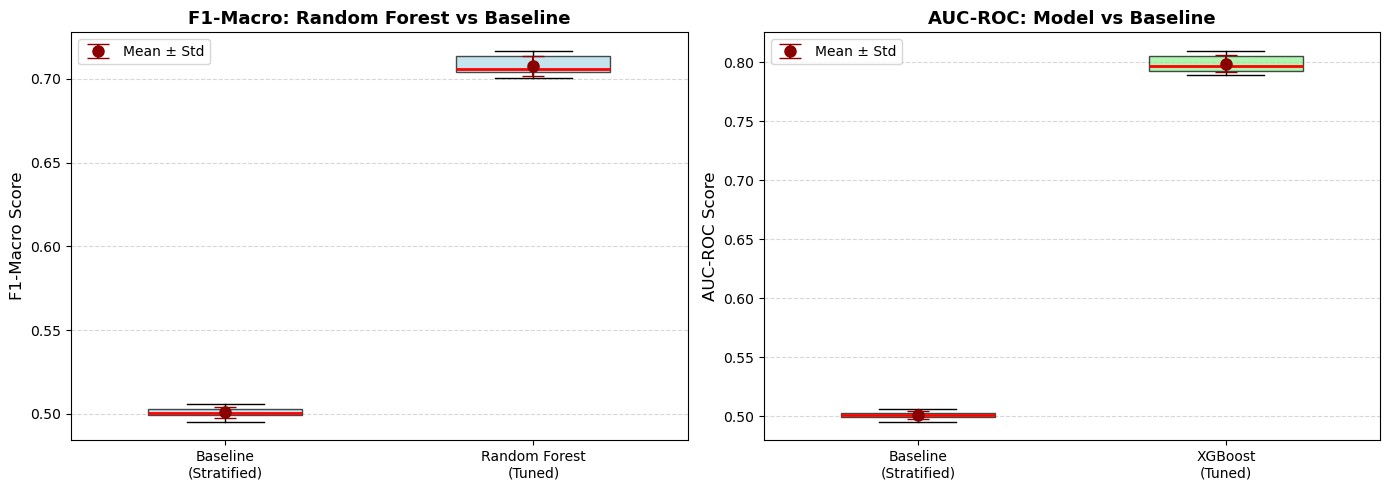

In [75]:
# 3. Visualization: Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1-Macro comparison
ax1 = axes[0]
positions = [1, 2]
box_data = [results_df['dummy_f1'], results_df['rf_f1']]

bp1 = ax1.boxplot(box_data, positions=positions, widths=0.5, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))

ax1.errorbar(positions, [results_df['dummy_f1'].mean(), results_df['rf_f1'].mean()],
             yerr=[results_df['dummy_f1'].std(), results_df['rf_f1'].std()],
             fmt='o', color='darkred', markersize=8, capsize=8, label='Mean ± Std')

ax1.set_xticks(positions)

ax1.set_xticklabels(['Baseline\n(Stratified)', 'Random Forest\n(Tuned)'])
ax1.set_ylabel('F1-Macro Score', fontsize=12)
ax1.set_title('F1-Macro: Random Forest vs Baseline', fontsize=13, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.legend()

# Plot 2: AUC-ROC comparison
ax2 = axes[1]
bp2 = ax2.boxplot([results_df['dummy_auc'], results_df['rf_auc']], 
                   positions=positions, widths=0.5, patch_artist=True,
                   boxprops=dict(facecolor='lightgreen', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))

ax2.errorbar(positions, [results_df['dummy_auc'].mean(), results_df['rf_auc'].mean()],
             yerr=[results_df['dummy_auc'].std(), results_df['rf_auc'].std()],
             fmt='o', color='darkred', markersize=8, capsize=8, label='Mean ± Std')
ax2.set_xticks(positions)
ax2.set_xticklabels(['Baseline\n(Stratified)', 'XGBoost\n(Tuned)'])
ax2.set_ylabel('AUC-ROC Score', fontsize=12)
ax2.set_title('AUC-ROC: Model vs Baseline', fontsize=13, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.savefig('presentation_plots/02_model_comparison_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()


MODEL INSPECTION (Final Split)

Classification Report:
              precision    recall  f1-score   support

          No     0.9445    0.8985    0.9209      7310
         Yes     0.4221    0.5841    0.4901       928

    accuracy                         0.8631      8238
   macro avg     0.6833    0.7413    0.7055      8238
weighted avg     0.8856    0.8631    0.8724      8238



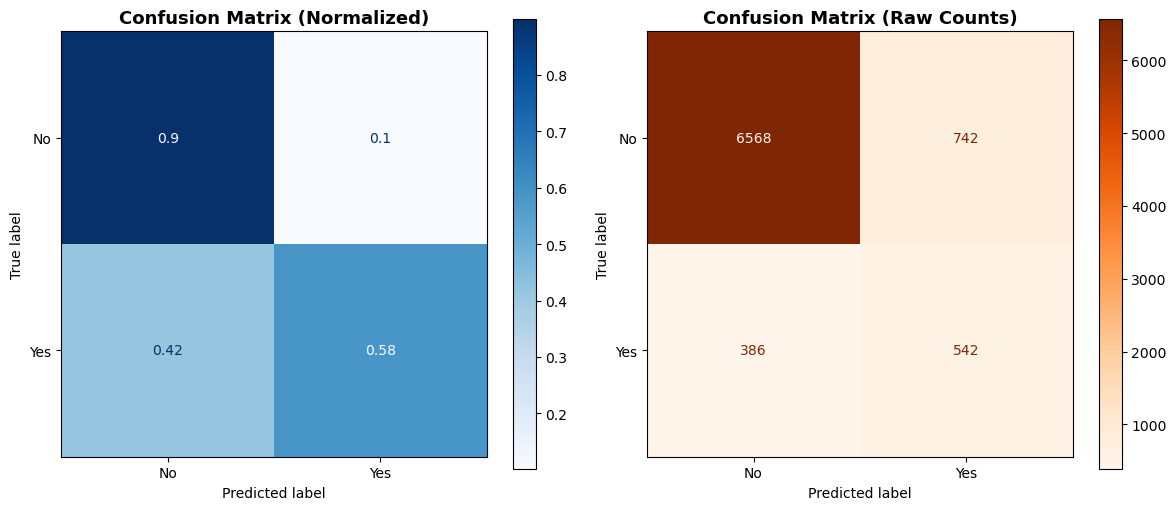

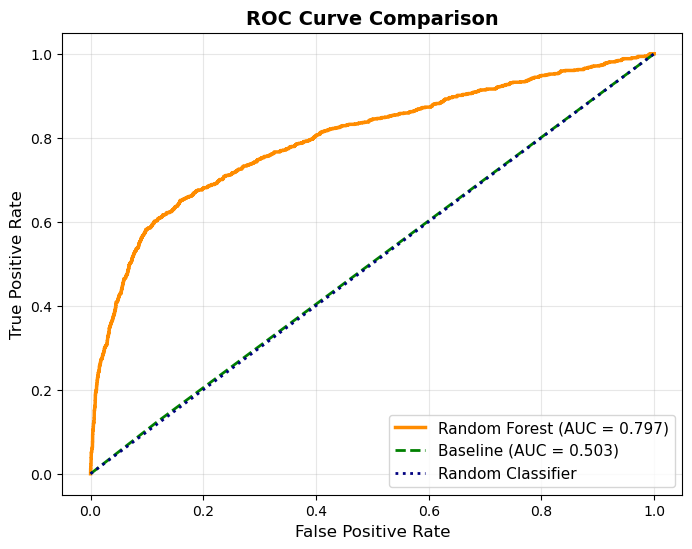

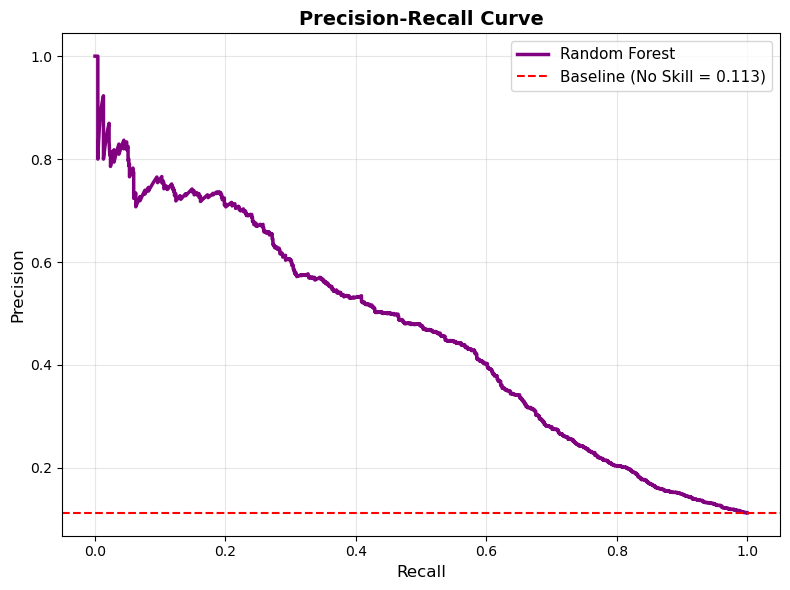

In [77]:
# 4. Model Inspection (using final split)
print(f"\n{'='*80}")
print("MODEL INSPECTION (Final Split)")
print(f"{'='*80}")


# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_te, y_pred_rf, target_names=['No', 'Yes'], digits=4))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normalized confusion matrix
ConfusionMatrixDisplay.from_estimator(
    rf_pipe, X_te, y_te, display_labels=['No', 'Yes'], 
    cmap='Blues', normalize='true', ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')

# Raw counts confusion matrix
ConfusionMatrixDisplay.from_estimator(
    rf_pipe, X_te, y_te, display_labels=['No', 'Yes'], 
    cmap='Oranges', normalize=None, ax=axes[1]
)
axes[1].set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('presentation_plots/03_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve
y_prob_final = rf_pipe.predict_proba(X_te)[:, 1]
fpr, tpr, thresholds = roc_curve(y_te, y_prob_final)
roc_auc = auc(fpr, tpr)

# Baseline ROC
y_prob_baseline = dummy.predict_proba(X_te)[:, 1]
fpr_base, tpr_base, _ = roc_curve(y_te, y_prob_baseline)
auc_base = auc(fpr_base, tpr_base)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, 
         label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot(fpr_base, tpr_base, color='green', lw=2, linestyle='--',
         label=f'Baseline (AUC = {auc_base:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle=':', lw=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout
plt.savefig('presentation_plots/04_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(y_te, y_prob_final)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2.5, label='Random Forest')
plt.axhline(y=np.sum(y_te)/len(y_te), color='red', linestyle='--', 
            label=f'Baseline (No Skill = {np.sum(y_te)/len(y_te):.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('presentation_plots/05_pre_recall.png', dpi=300, bbox_inches='tight')
plt.show()


GLOBAL FEATURE IMPORTANCE (3 Methods)

shap_importance shape after processing: (40,)
shap_importance length: 40

Top 15 Features by Each Method:
--------------------------------------------------------------------------------
         Impurity_Feature  Impurity_Score          Perm_Feature  Perm_Score           SHAP_Feature  SHAP_Score
         num__nr.employed        0.209182      nom__job_retired    0.065866       num__nr.employed    0.074855
      num__cons.price.idx        0.100913   nom__job_management    0.020430 nom__contact_telephone    0.029104
       num__cons.conf.idx        0.090860      nom__job_missing    0.010516  nom__contact_cellular    0.023723
                 num__age        0.075038        ord__education    0.008266     num__cons.conf.idx    0.023636
               num__pdays        0.060488            ord__month    0.004459    num__cons.price.idx    0.019467
               ord__month        0.055213    nom__job_housemaid    0.003608             num__pdays    0.018

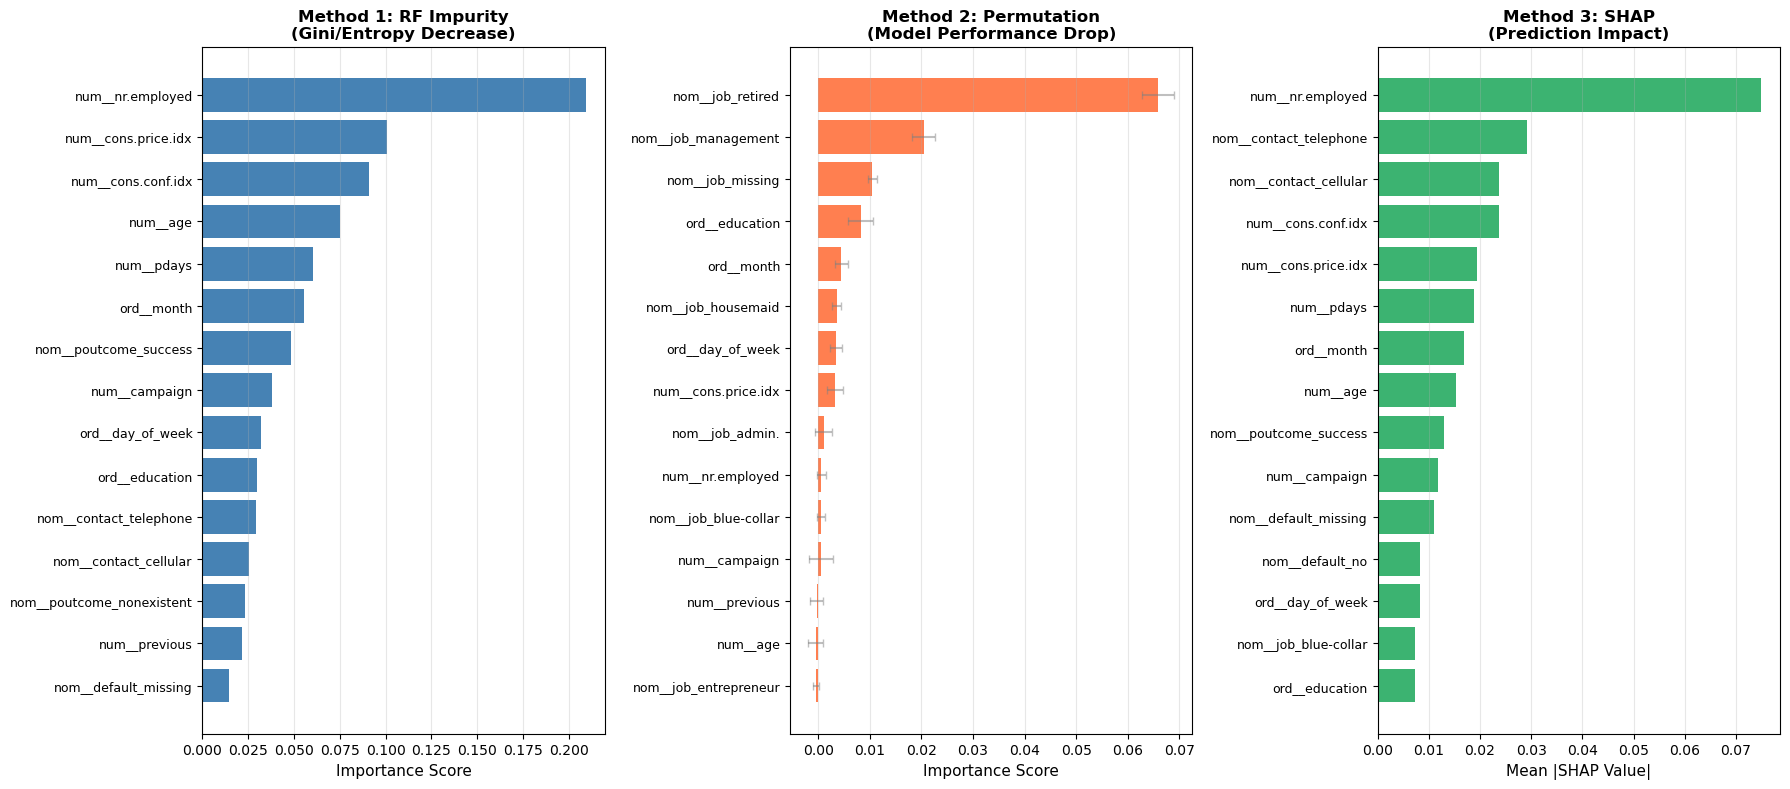

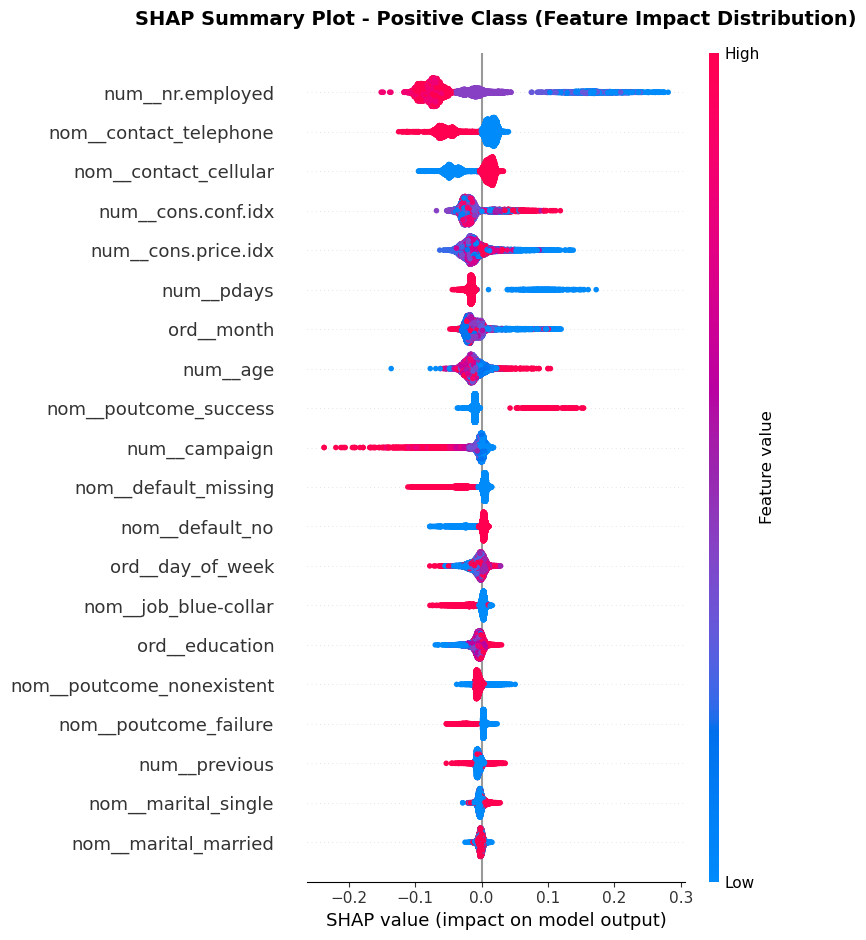

In [79]:
# Global Feature Importance
print(f"\n{'='*80}")
print("GLOBAL FEATURE IMPORTANCE (3 Methods)")
print(f"{'='*80}\n")

rf_model = rf_pipe.named_steps['classifier']
feature_names = rf_pipe.named_steps['preprocessor'].get_feature_names_out()

# Method 1: XGBoost Built-in Gain
importances_gain = rf_model.feature_importances_
idx_gain = np.argsort(importances_gain)[::-1]

# Method 2: Permutation Importance
perm_results = permutation_importance(
    rf_pipe, 
    X_te, y_te, 
    n_repeats=10, 
    random_state=42, 
    scoring='f1_macro',
    n_jobs=-1
)
idx_perm = perm_results.importances_mean.argsort()[::-1]

# Method 3: SHAP Values
X_te_trans = rf_pipe.named_steps['preprocessor'].transform(X_te)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_te_trans, check_additivity=False)

if len(shap_values.shape) == 3 and shap_values.shape[2] == 2:
    # only takes when index = 1
    shap_importance = np.abs(shap_values[:, :, 1]).mean(axis=0)
else:
    shap_importance = np.abs(shap_values).mean(axis=0)

print(f"shap_importance shape after processing: {shap_importance.shape}")
print(f"shap_importance length: {len(shap_importance)}")
print()

idx_shap = np.argsort(shap_importance)[::-1]

# Display top 15 features from each method
n_top = 15
print(f"Top {n_top} Features by Each Method:")
print("-" * 80)

comparison_df = pd.DataFrame({
    'Impurity_Feature': feature_names[idx_gain[:n_top]],
    'Impurity_Score': importances_gain[idx_gain[:n_top]],
    'Perm_Feature': feature_names[idx_perm[:n_top]],
    'Perm_Score': perm_results.importances_mean[idx_perm[:n_top]],
    'SHAP_Feature': feature_names[idx_shap[:n_top]],
    'SHAP_Score': shap_importance[idx_shap[:n_top]]
})
print(comparison_df.to_string(index=False))

# Visualization: 3 methods side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Plot 1: Random Forest Impurity-based Importance
top_n = 15
axes[0].barh(range(top_n), importances_gain[idx_gain[:top_n]], color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(feature_names[idx_gain[:top_n]], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Method 1: RF Impurity\n(Gini/Entropy Decrease)', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Permutation Importance
perm_top_indices = idx_perm[:top_n]
axes[1].barh(range(top_n), perm_results.importances_mean[perm_top_indices], color='coral')
axes[1].errorbar(perm_results.importances_mean[perm_top_indices], range(top_n),
                 xerr=perm_results.importances_std[perm_top_indices],
                 fmt='none', ecolor='gray', alpha=0.5, capsize=3)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(feature_names[perm_top_indices], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance Score', fontsize=11)
axes[1].set_title('Method 2: Permutation\n(Model Performance Drop)', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Plot 3: SHAP Values
axes[2].barh(range(top_n), shap_importance[idx_shap[:top_n]], color='mediumseagreen')
axes[2].set_yticks(range(top_n))
axes[2].set_yticklabels(feature_names[idx_shap[:top_n]], fontsize=9)
axes[2].invert_yaxis()
axes[2].set_xlabel('Mean |SHAP Value|', fontsize=11)
axes[2].set_title('Method 3: SHAP\n(Prediction Impact)', fontsize=12, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('presentation_plots/05_feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[:, :, 1], X_te_trans, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Positive Class (Feature Impact Distribution)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('presentation_plots/06_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()


LOCAL INTERPRETATION (Individual Predictions)


Explaining True Positive (Test Index: 2)
  True Label: Yes
  Predicted: Yes
  Probability: 0.8395


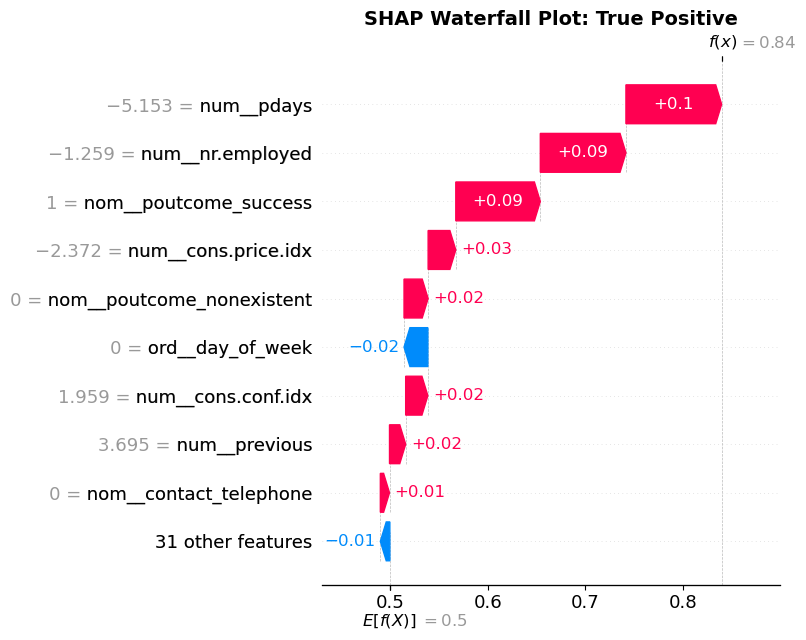


Explaining False Positive (Test Index: 16)
  True Label: No
  Predicted: Yes
  Probability: 0.5232


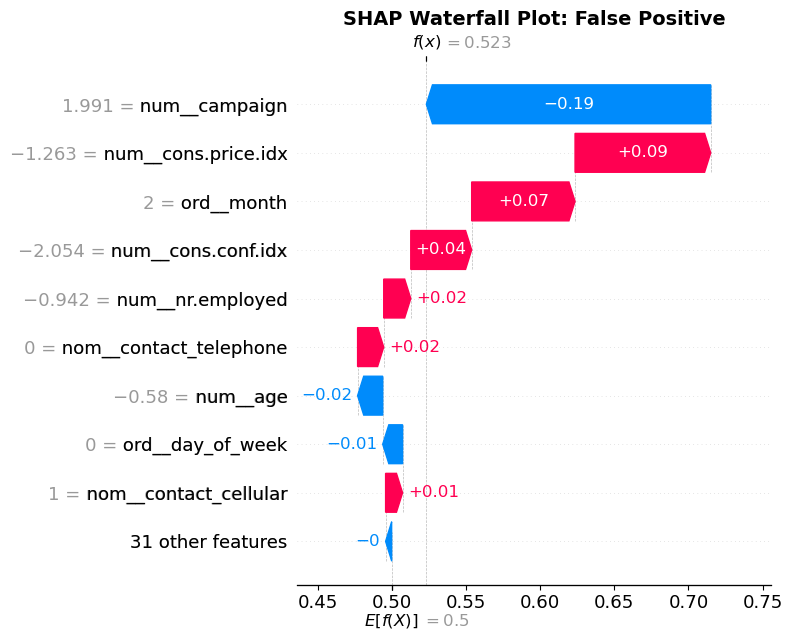

In [81]:
# Local Interpretation
print(f"\n{'='*80}")
print("LOCAL INTERPRETATION (Individual Predictions)")
print(f"{'='*80}\n")

# Find interesting cases
yes_pred_indices = np.where(rf_pipe.predict(X_te) == 1)[0]  # 改为 rf_pipe
no_pred_indices = np.where(rf_pipe.predict(X_te) == 0)[0]   # 改为 rf_pipe

# Select one True Positive and one False Positive (if available)
tp_indices = [i for i in yes_pred_indices if y_te.iloc[i] == 1]
fp_indices = [i for i in yes_pred_indices if y_te.iloc[i] == 0]

cases_to_explain = []
if len(tp_indices) > 0:
    cases_to_explain.append(('True Positive', tp_indices[0]))
if len(fp_indices) > 0:
    cases_to_explain.append(('False Positive', fp_indices[0]))

for case_name, idx in cases_to_explain:
    print(f"\nExplaining {case_name} (Test Index: {idx})")
    print(f"  True Label: {'Yes' if y_te.iloc[idx]==1 else 'No'}")
    print(f"  Predicted: {'Yes' if rf_pipe.predict(X_te)[idx]==1 else 'No'}")  # 改为 rf_pipe
    print(f"  Probability: {rf_pipe.predict_proba(X_te)[idx, 1]:.4f}")  # 改为 rf_pipe
    
    # 关键修复：处理二分类 SHAP 值
    # shap_values 形状是 (n_samples, n_features, 2)，取正类的值 [:, :, 1]
    if len(shap_values.shape) == 3:
        # 二分类：取正类（索引1）
        shap_value_for_sample = shap_values[idx, :, 1]
        expected_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    else:
        # 其他情况
        shap_value_for_sample = shap_values[idx]
        expected_value = explainer.expected_value
    
    explanation = shap.Explanation(
        values=shap_value_for_sample,
        base_values=expected_value,
        data=X_te_trans[idx],
        feature_names=feature_names
    )
    
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, show=False)
    plt.title(f'SHAP Waterfall Plot: {case_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'presentation_plots/07_shap_waterfall_{case_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [57]:
import os
import matplotlib.pyplot as plt

# 创建一个文件夹用来存高清图
if not os.path.exists('presentation_plots'):
    os.makedirs('presentation_plots')
